# 02 ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â Exploratory Data Analysis

Load cleaned data from `outputs/results/data_clean.parquet`. No raw CSVs are read here.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, os.path.abspath('..'))

import config
from src.utils import full_value_counts, get_relative_trigger

Path(config.PLOTS_PATH).mkdir(parents=True, exist_ok=True)

%matplotlib inline

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

print(sys.path)
print(os.path.abspath('..'))

import src.utils
print(dir(src.utils))

['c:\\Users\\timot\\fraud_model\\fraud_model', 'c:\\Users\\timot\\fraud_model\\fraud_model', 'C:\\Users\\timot\\miniconda3\\python313.zip', 'C:\\Users\\timot\\miniconda3\\DLLs', 'C:\\Users\\timot\\miniconda3\\Lib', 'C:\\Users\\timot\\miniconda3', 'c:\\Users\\timot\\fraud_model\\fraud_model\\fraud_env', '', 'c:\\Users\\timot\\fraud_model\\fraud_model\\fraud_env\\Lib\\site-packages']
c:\Users\timot\fraud_model\fraud_model
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'full_value_counts', 'get_relative_trigger', 'np', 'pd']


In [3]:
df = pd.read_parquet(config.RESULTS_PATH / 'data_clean.parquet')
print(df.shape)
df.head()

(590540, 362)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_29,id_31,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,hour_of_day,day_of_week
0,2987000,0,2017-12-01 00:00:00,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4
1,2987001,0,2017-12-01 00:00:01,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4
2,2987002,0,2017-12-01 00:01:09,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4
3,2987003,0,2017-12-01 00:01:39,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4
4,2987004,0,2017-12-01 00:01:46,50.0,H,4497,514.0,150.0,mastercard,102.0,...,NotFound,samsung browser 6.2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,0,4


## Fraud Time Series

Examine fraud across actual calendar time. Daily aggregation shows macro trends; hourly reveals intraday structure.

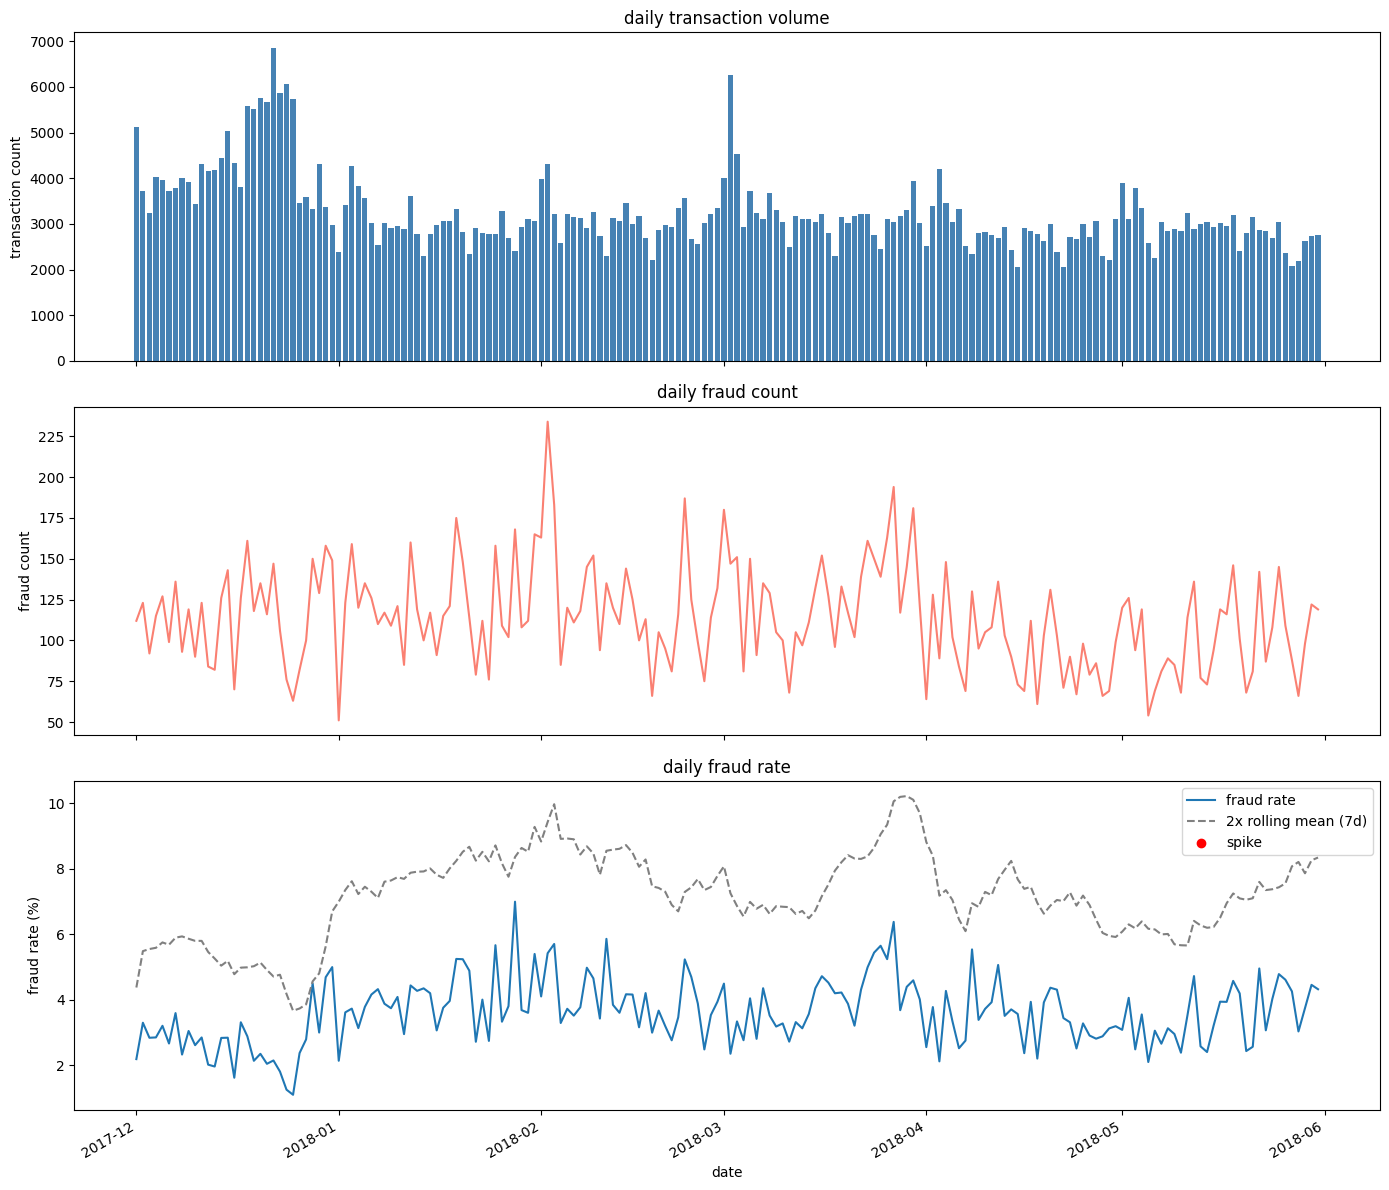

In [4]:
daily = (df.groupby(df['TransactionDT'].dt.normalize())
           .agg(total=(config.TARGET, 'count'), fraud=(config.TARGET, 'sum'))
           .reset_index()
           .rename(columns={'TransactionDT': 'date'}))
daily['fraud_rate'] = daily['fraud'] / daily['total'] * 100
daily['rolling_mean'] = daily['fraud_rate'].rolling(7, min_periods=1).mean()
anomalies = daily[daily['fraud_rate'] > 2 * daily['rolling_mean']]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].bar(daily['date'], daily['total'], width=0.8, color='steelblue')
axes[0].set_ylabel('transaction count')
axes[0].set_title('daily transaction volume')

axes[1].plot(daily['date'], daily['fraud'], color='salmon')
axes[1].set_ylabel('fraud count')
axes[1].set_title('daily fraud count')

axes[2].plot(daily['date'], daily['fraud_rate'], label='fraud rate')
axes[2].plot(daily['date'], daily['rolling_mean'] * 2, linestyle='--', color='grey', label='2x rolling mean (7d)')
axes[2].scatter(anomalies['date'], anomalies['fraud_rate'], color='red', zorder=5, label='spike')
for _, row in anomalies.iterrows():
    axes[2].annotate(
        row['date'].strftime('%m/%d'),
        xy=(row['date'], row['fraud_rate']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=7, color='red'
    )
axes[2].set_ylabel('fraud rate (%)')
axes[2].set_xlabel('date')
axes[2].set_title('daily fraud rate')
axes[2].legend()

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_timeseries_daily.png')
plt.show()
plt.close()

Interestingly, the highest txn volume appears in the 2017 holiday season, and then fraud rates appear to pick up in 2018.

No major anomalies noted. 

Note: Volume dips at dataset edges are expected â€” partial days or low-activity periods. Red-annotated spikes are days where fraud rate exceeded twice the 7-day rolling mean; cross-reference with the hourly chart to determine whether a spike is sustained or isolated.

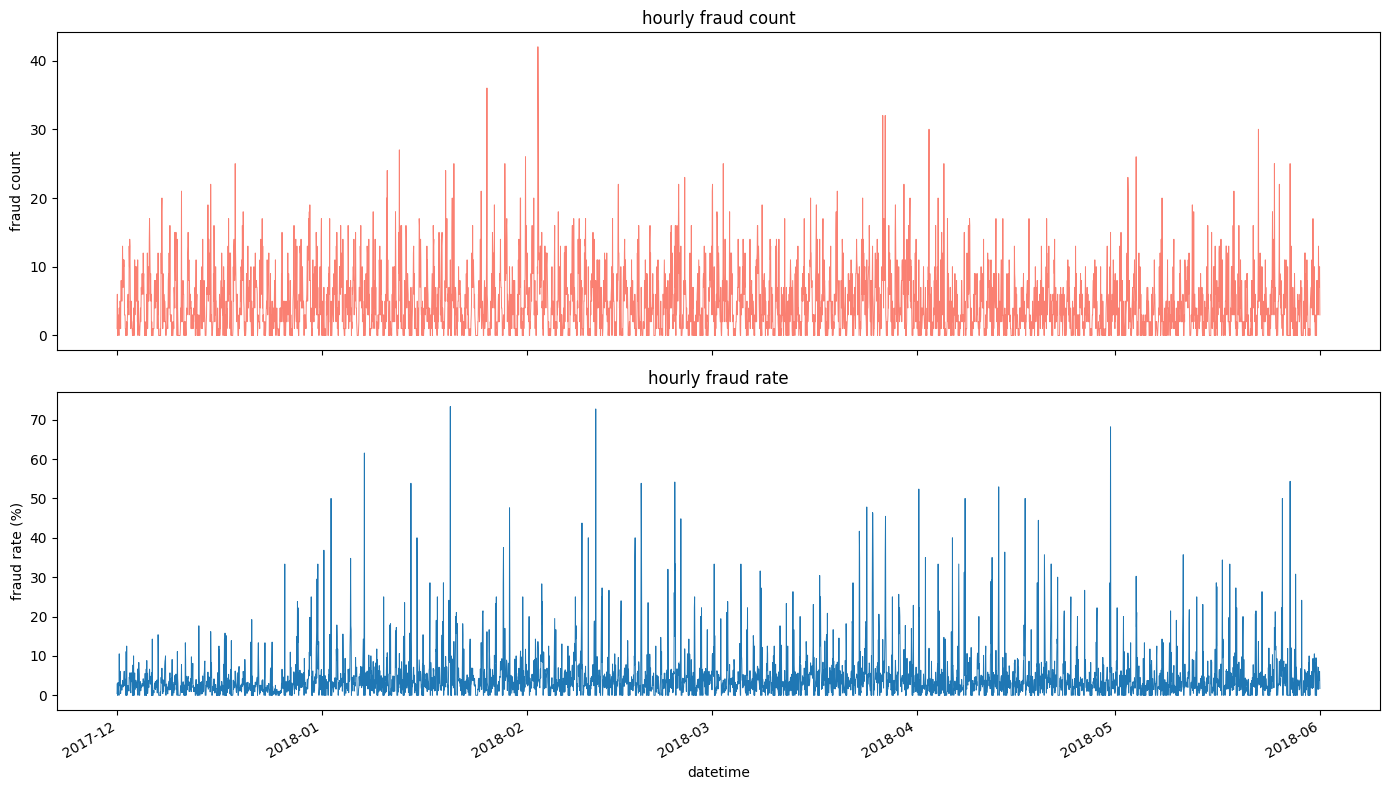

In [5]:
hourly = (df.groupby(df['TransactionDT'].dt.floor('h'))
            .agg(total=(config.TARGET, 'count'), fraud=(config.TARGET, 'sum'))
            .reset_index()
            .rename(columns={'TransactionDT': 'hour_ts'}))
hourly['fraud_rate'] = hourly['fraud'] / hourly['total'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(hourly['hour_ts'], hourly['fraud'], linewidth=0.7, color='salmon')
axes[0].set_ylabel('fraud count')
axes[0].set_title('hourly fraud count')

axes[1].plot(hourly['hour_ts'], hourly['fraud_rate'], linewidth=0.7)
axes[1].set_ylabel('fraud rate (%)')
axes[1].set_xlabel('datetime')
axes[1].set_title('hourly fraud rate')

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_timeseries_hourly.png')
plt.show()
plt.close()

Sustained elevated fraud rate across consecutive hours suggests organized or automated fraud. Single-hour spikes with low transaction volume are more likely noise. Compare against the daily chart â€” anomalous days should show clusters of elevated hourly rates.

## 1. Fraud Over Time

Volume shows absolute fraud counts; rate normalises for transaction density across hours and days.

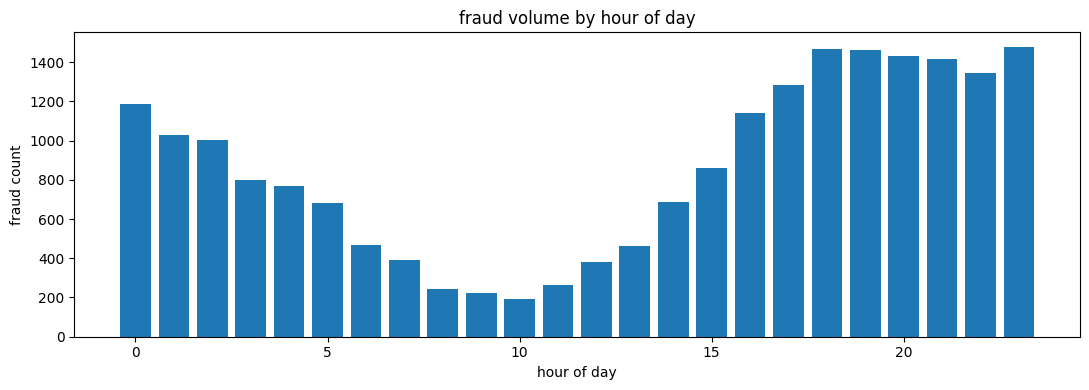

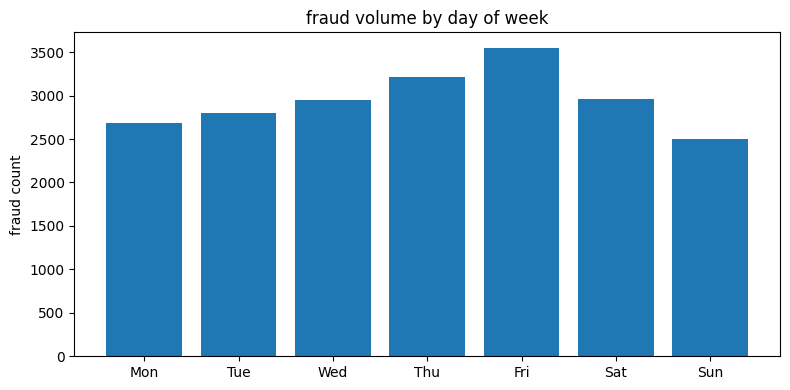

In [6]:
hour_vol = df.groupby('hour_of_day')[config.TARGET].sum()
dow_vol  = df.groupby('day_of_week')[config.TARGET].sum()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hour_vol.index, hour_vol.values)
ax.set_xlabel('hour of day')
ax.set_ylabel('fraud count')
ax.set_title('fraud volume by hour of day')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_volume_by_hour.png')
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow_vol.index, dow_vol.values)
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_ylabel('fraud count')
ax.set_title('fraud volume by day of week')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_volume_by_dow.png')
plt.show()
plt.close()

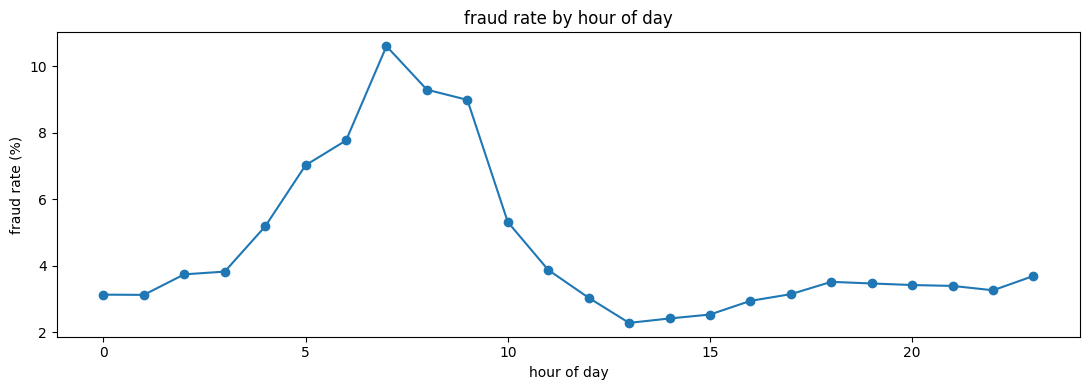

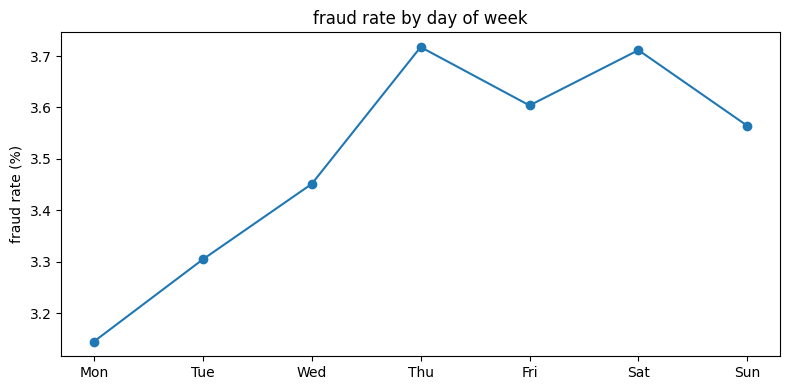

peak fraud rate hour: 7:00 (10.61%)
peak fraud rate day:  Thu (3.72%)


In [7]:
hour_rate = df.groupby('hour_of_day')[config.TARGET].mean() * 100
dow_rate  = df.groupby('day_of_week')[config.TARGET].mean() * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hour_rate.index, hour_rate.values, marker='o')
ax.set_xlabel('hour of day')
ax.set_ylabel('fraud rate (%)')
ax.set_title('fraud rate by hour of day')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_rate_by_hour.png')
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dow_rate.index, dow_rate.values, marker='o')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_ylabel('fraud rate (%)')
ax.set_title('fraud rate by day of week')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_rate_by_dow.png')
plt.show()
plt.close()

peak_hour = int(hour_rate.idxmax())
peak_dow  = dow_labels[int(dow_rate.idxmax())]
print(f'peak fraud rate hour: {peak_hour}:00 ({hour_rate.max():.2f}%)')
print(f'peak fraud rate day:  {peak_dow} ({dow_rate.max():.2f}%)')

## 2. Transaction Amount Analysis

The raw distribution is heavily right-skewed. Log transform reveals structure that would otherwise be hidden.

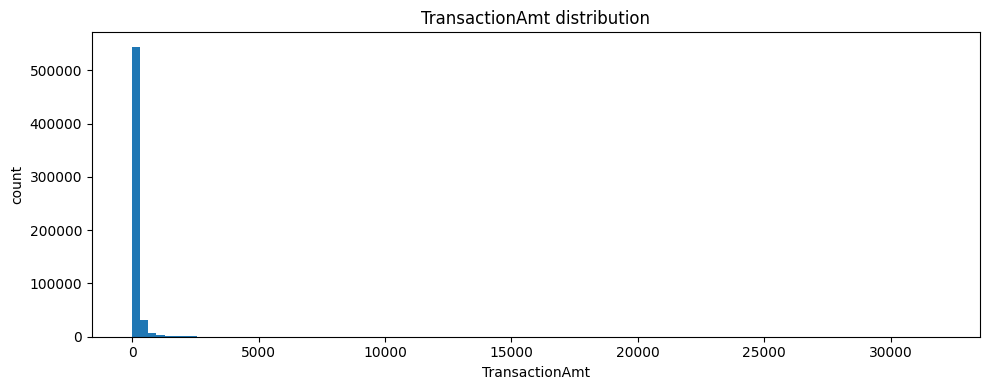

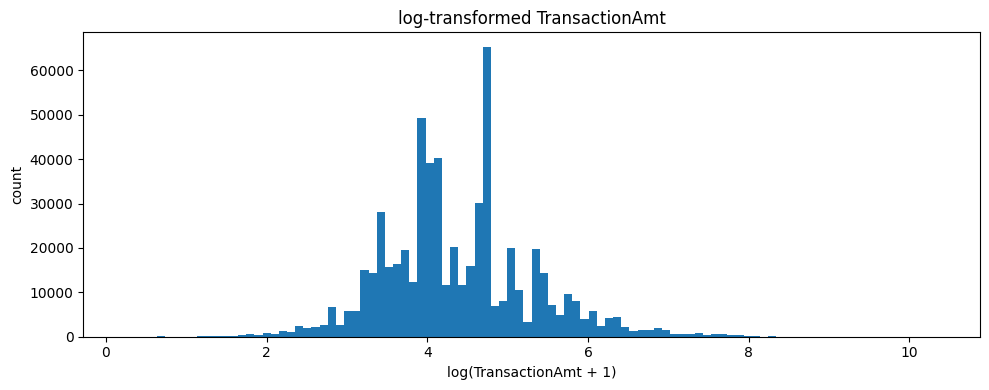

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['TransactionAmt'], bins=100)
ax.set_xlabel('TransactionAmt')
ax.set_ylabel('count')
ax.set_title('TransactionAmt distribution')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'txn_amt_dist.png')
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log1p(df['TransactionAmt']), bins=100)
ax.set_xlabel('log(TransactionAmt + 1)')
ax.set_ylabel('count')
ax.set_title('log-transformed TransactionAmt')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'txn_amt_log_dist.png')
plt.show()
plt.close()

C:\Users\timot\AppData\Local\Temp\ipykernel_90004\1883917250.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([legit_amt, fraud_amt], labels=['legitimate', 'fraud'], sym='')


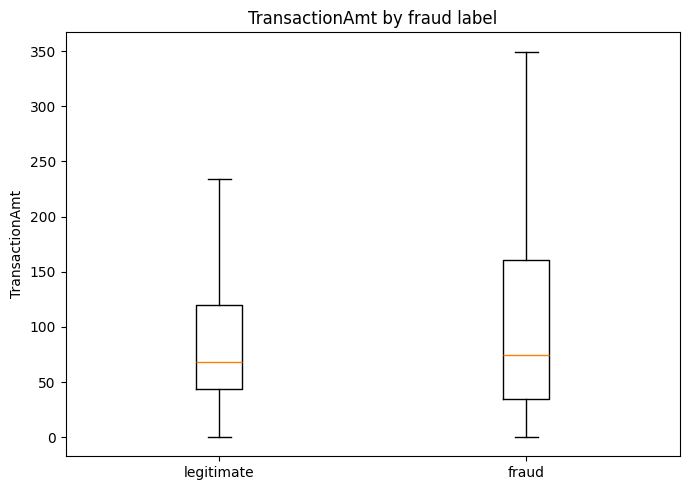

legit - median: 68.50, mean: 134.51
fraud - median: 75.00, mean: 149.24


In [9]:
fraud_amt = df[df[config.TARGET] == 1]['TransactionAmt']
legit_amt = df[df[config.TARGET] == 0]['TransactionAmt']

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([legit_amt, fraud_amt], labels=['legitimate', 'fraud'], sym='')
ax.set_ylabel('TransactionAmt')
ax.set_title('TransactionAmt by fraud label')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'txn_amt_boxplot.png')
plt.show()
plt.close()

for label, grp in df.groupby(config.TARGET)['TransactionAmt']:
    tag = 'fraud' if label == 1 else 'legit'
    print(f'{tag} - median: {grp.median():.2f}, mean: {grp.mean():.2f}')

## 3. Categorical Analysis

For each field: volume breakdown via `full_value_counts()` and fraud penetration sorted by fraud rate.

              cnt       pct
ProductCD                  
W          439670  0.744522
C           68519  0.116028
R           37699  0.063838
H           33024  0.055922
S           11628  0.019690


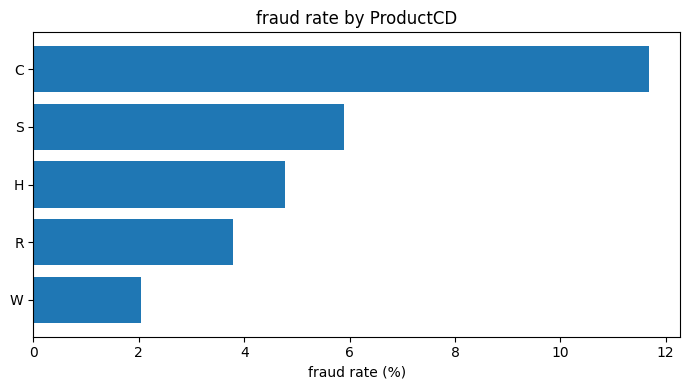

In [10]:
print(full_value_counts(df, 'ProductCD'))

fraud_rate = df.groupby('ProductCD')[config.TARGET].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(fraud_rate.index.astype(str), fraud_rate.values * 100)
ax.set_xlabel('fraud rate (%)')
ax.set_title('fraud rate by ProductCD')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_rate_productcd.png')
plt.show()
plt.close()

                     cnt       pct
card4                             
visa              384767  0.653296
mastercard        189217  0.321271
american express    8328  0.014140
discover            6651  0.011293


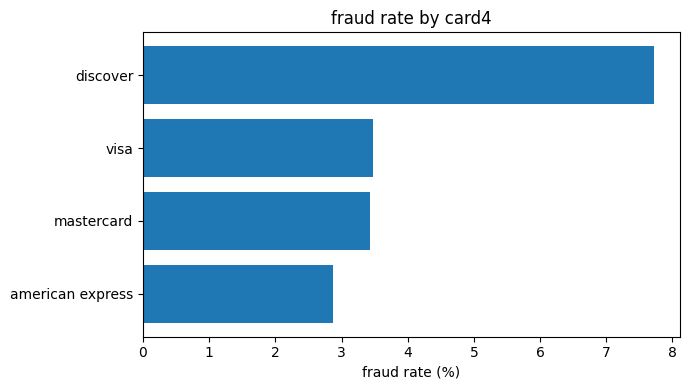

In [11]:
print(full_value_counts(df, 'card4'))

fraud_rate = df.groupby('card4')[config.TARGET].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(fraud_rate.index.astype(str), fraud_rate.values * 100)
ax.set_xlabel('fraud rate (%)')
ax.set_title('fraud rate by card4')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_rate_card4.png')
plt.show()
plt.close()

                    cnt       pct
card6                            
debit            439938  0.746963
credit           148986  0.252961
debit or credit      30  0.000051
charge card          15  0.000025


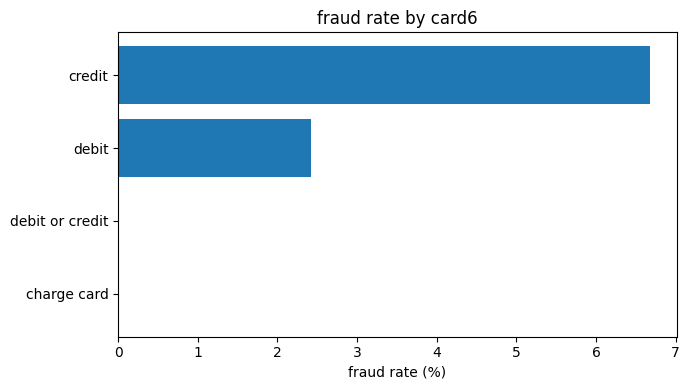

In [12]:
print(full_value_counts(df, 'card6'))

fraud_rate = df.groupby('card6')[config.TARGET].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(fraud_rate.index.astype(str), fraud_rate.values * 100)
ax.set_xlabel('fraud rate (%)')
ax.set_title('fraud rate by card6')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_rate_card6.png')
plt.show()
plt.close()

                  cnt       pct
P_emaildomain                  
gmail.com      228355  0.460315
yahoo.com      100934  0.203462
hotmail.com     45250  0.091214
anonymous.com   36998  0.074580
aol.com         28289  0.057025
comcast.net      7888  0.015901
icloud.com       6267  0.012633
outlook.com      5096  0.010272
msn.com          4092  0.008249
att.net          4033  0.008130
live.com         3041  0.006130
sbcglobal.net    2970  0.005987
verizon.net      2705  0.005453
ymail.com        2396  0.004830
bellsouth.net    1909  0.003848


C:\Users\timot\AppData\Local\Temp\ipykernel_90004\3867882555.py:11: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\timot\AppData\Local\Temp\ipykernel_90004\3867882555.py:12: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.savefig(config.PLOTS_PATH / 'fraud_rate_p_emaildomain.png')
c:\Users\timot\fraud_model\fraud_model\fraud_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


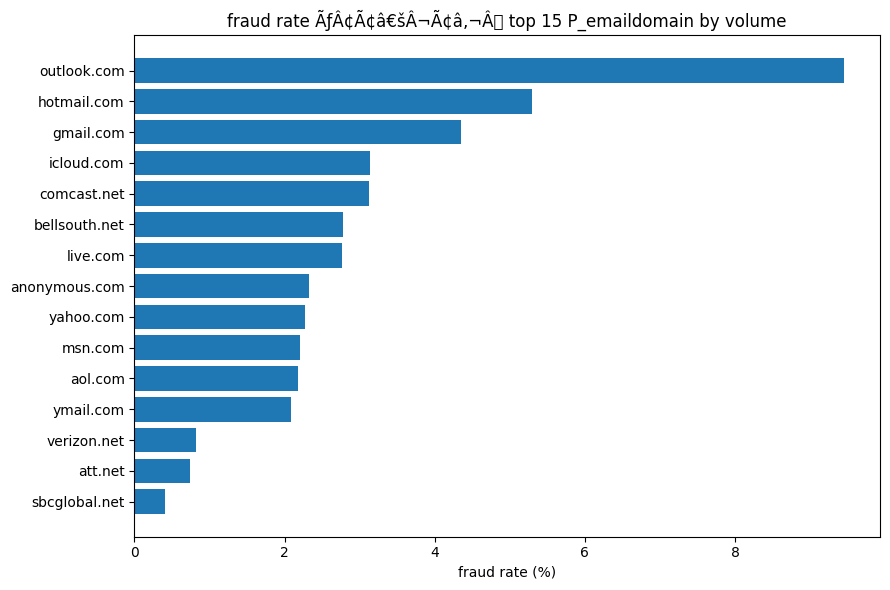

In [13]:
top_p_email = df['P_emaildomain'].value_counts().head(15).index
print(full_value_counts(df, 'P_emaildomain').head(15))

fraud_rate = (df[df['P_emaildomain'].isin(top_p_email)]
              .groupby('P_emaildomain')[config.TARGET].mean()
              .sort_values())
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fraud_rate.index.astype(str), fraud_rate.values * 100)
ax.set_xlabel('fraud rate (%)')
ax.set_title('fraud rate ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â top 15 P_emaildomain by volume')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_rate_p_emaildomain.png')
plt.show()
plt.close()

                 cnt       pct
R_emaildomain                 
gmail.com      57147  0.416247
hotmail.com    27509  0.200370
anonymous.com  20529  0.149529
yahoo.com      11842  0.086255
aol.com         3701  0.026957
outlook.com     2507  0.018260
comcast.net     1812  0.013198
yahoo.com.mx    1508  0.010984
icloud.com      1398  0.010183
msn.com          852  0.006206
live.com         762  0.005550
live.com.mx      754  0.005492
verizon.net      620  0.004516
me.com           556  0.004050
sbcglobal.net    552  0.004021


C:\Users\timot\AppData\Local\Temp\ipykernel_90004\2728537383.py:11: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\timot\AppData\Local\Temp\ipykernel_90004\2728537383.py:12: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.savefig(config.PLOTS_PATH / 'fraud_rate_r_emaildomain.png')
c:\Users\timot\fraud_model\fraud_model\fraud_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


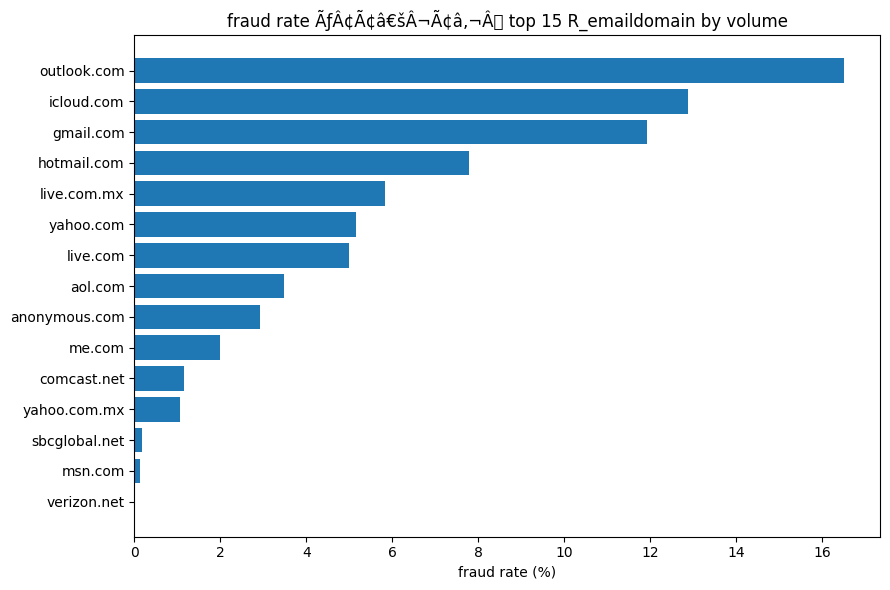

In [14]:
top_r_email = df['R_emaildomain'].value_counts().head(15).index
print(full_value_counts(df, 'R_emaildomain').head(15))

fraud_rate = (df[df['R_emaildomain'].isin(top_r_email)]
              .groupby('R_emaildomain')[config.TARGET].mean()
              .sort_values())
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fraud_rate.index.astype(str), fraud_rate.values * 100)
ax.set_xlabel('fraud rate (%)')
ax.set_title('fraud rate ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â top 15 R_emaildomain by volume')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_rate_r_emaildomain.png')
plt.show()
plt.close()

         cnt       pct
addr1                 
299.0  46335  0.088285
325.0  42751  0.081456
204.0  42020  0.080063
264.0  39870  0.075967
330.0  26287  0.050086
315.0  23078  0.043972
441.0  20827  0.039683
272.0  20141  0.038376
123.0  16105  0.030686
126.0  15243  0.029043
184.0  15160  0.028885
337.0  15149  0.028864
191.0  14979  0.028540
181.0  13856  0.026401
143.0   9806  0.018684


C:\Users\timot\AppData\Local\Temp\ipykernel_90004\358957687.py:11: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\timot\AppData\Local\Temp\ipykernel_90004\358957687.py:12: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.savefig(config.PLOTS_PATH / 'fraud_rate_addr1.png')
c:\Users\timot\fraud_model\fraud_model\fraud_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


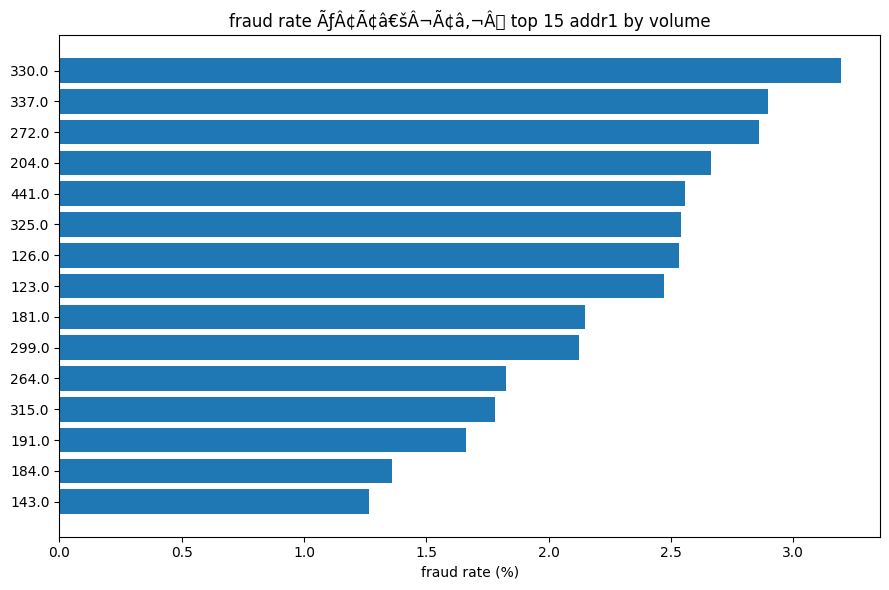

In [15]:
top_addr1 = df['addr1'].value_counts().head(15).index
print(full_value_counts(df, 'addr1').head(15))

fraud_rate = (df[df['addr1'].isin(top_addr1)]
              .groupby('addr1')[config.TARGET].mean()
              .sort_values())
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fraud_rate.index.astype(str), fraud_rate.values * 100)
ax.set_xlabel('fraud rate (%)')
ax.set_title('fraud rate ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â top 15 addr1 by volume')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_rate_addr1.png')
plt.show()
plt.close()

## 4. Device Analysis

Device fields are only populated for the ~30% of transactions with identity data. Interpret fraud rates in that context.

              cnt       pct
DeviceType                 
desktop     85165  0.604822
mobile      55645  0.395178


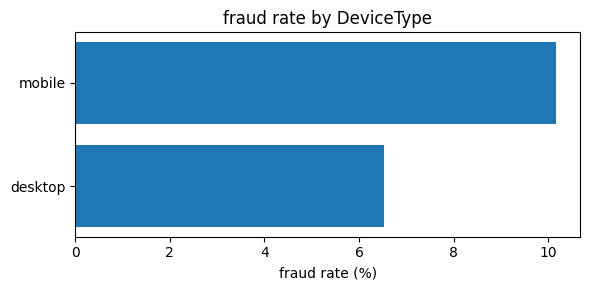

In [16]:
print(full_value_counts(df, 'DeviceType'))

fraud_rate = df.groupby('DeviceType')[config.TARGET].mean().sort_values()
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(fraud_rate.index.astype(str), fraud_rate.values * 100)
ax.set_xlabel('fraud rate (%)')
ax.set_title('fraud rate by DeviceType')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_rate_devicetype.png')
plt.show()
plt.close()

                               cnt       pct
DeviceInfo                                  
Windows                      47722  0.402154
iOS Device                   19782  0.166703
MacOS                        12573  0.105953
Trident/7.0                   7440  0.062697
rv:11.0                       1901  0.016020
rv:57.0                        962  0.008107
SM-J700M Build/MMB29K          549  0.004626
SM-G610M Build/MMB29K          461  0.003885
SM-G531H Build/LMY48B          410  0.003455
rv:59.0                        362  0.003051
SM-G935F Build/NRD90M          334  0.002815
SM-G955U Build/NRD90M          328  0.002764
SM-G532M Build/MMB29T          316  0.002663
ALE-L23 Build/HuaweiALE-L23    312  0.002629
SM-G950U Build/NRD90M          290  0.002444


C:\Users\timot\AppData\Local\Temp\ipykernel_90004\682098236.py:11: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\timot\AppData\Local\Temp\ipykernel_90004\682098236.py:12: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.savefig(config.PLOTS_PATH / 'fraud_rate_deviceinfo.png')
c:\Users\timot\fraud_model\fraud_model\fraud_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


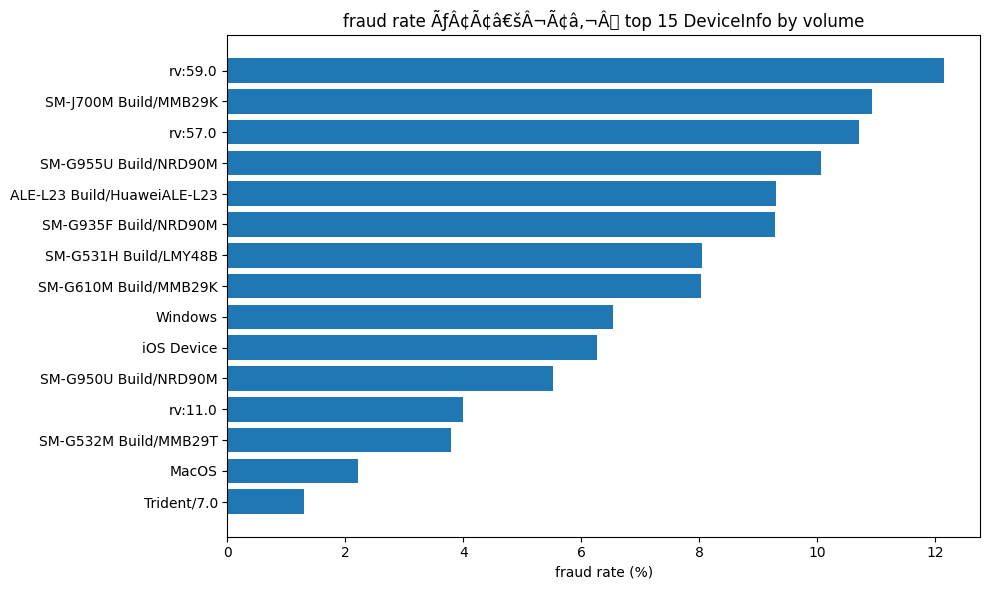

In [17]:
top_devices = df['DeviceInfo'].value_counts().head(15).index
print(full_value_counts(df, 'DeviceInfo').head(15))

fraud_rate = (df[df['DeviceInfo'].isin(top_devices)]
              .groupby('DeviceInfo')[config.TARGET].mean()
              .sort_values())
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fraud_rate.index.astype(str), fraud_rate.values * 100)
ax.set_xlabel('fraud rate (%)')
ax.set_title('fraud rate ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â top 15 DeviceInfo by volume')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'fraud_rate_deviceinfo.png')
plt.show()
plt.close()

## 5. Match Fields (M1ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“M9)

M columns flag whether fields match across the transaction (e.g. name on card vs. billing address). Values are T, F, or missing.

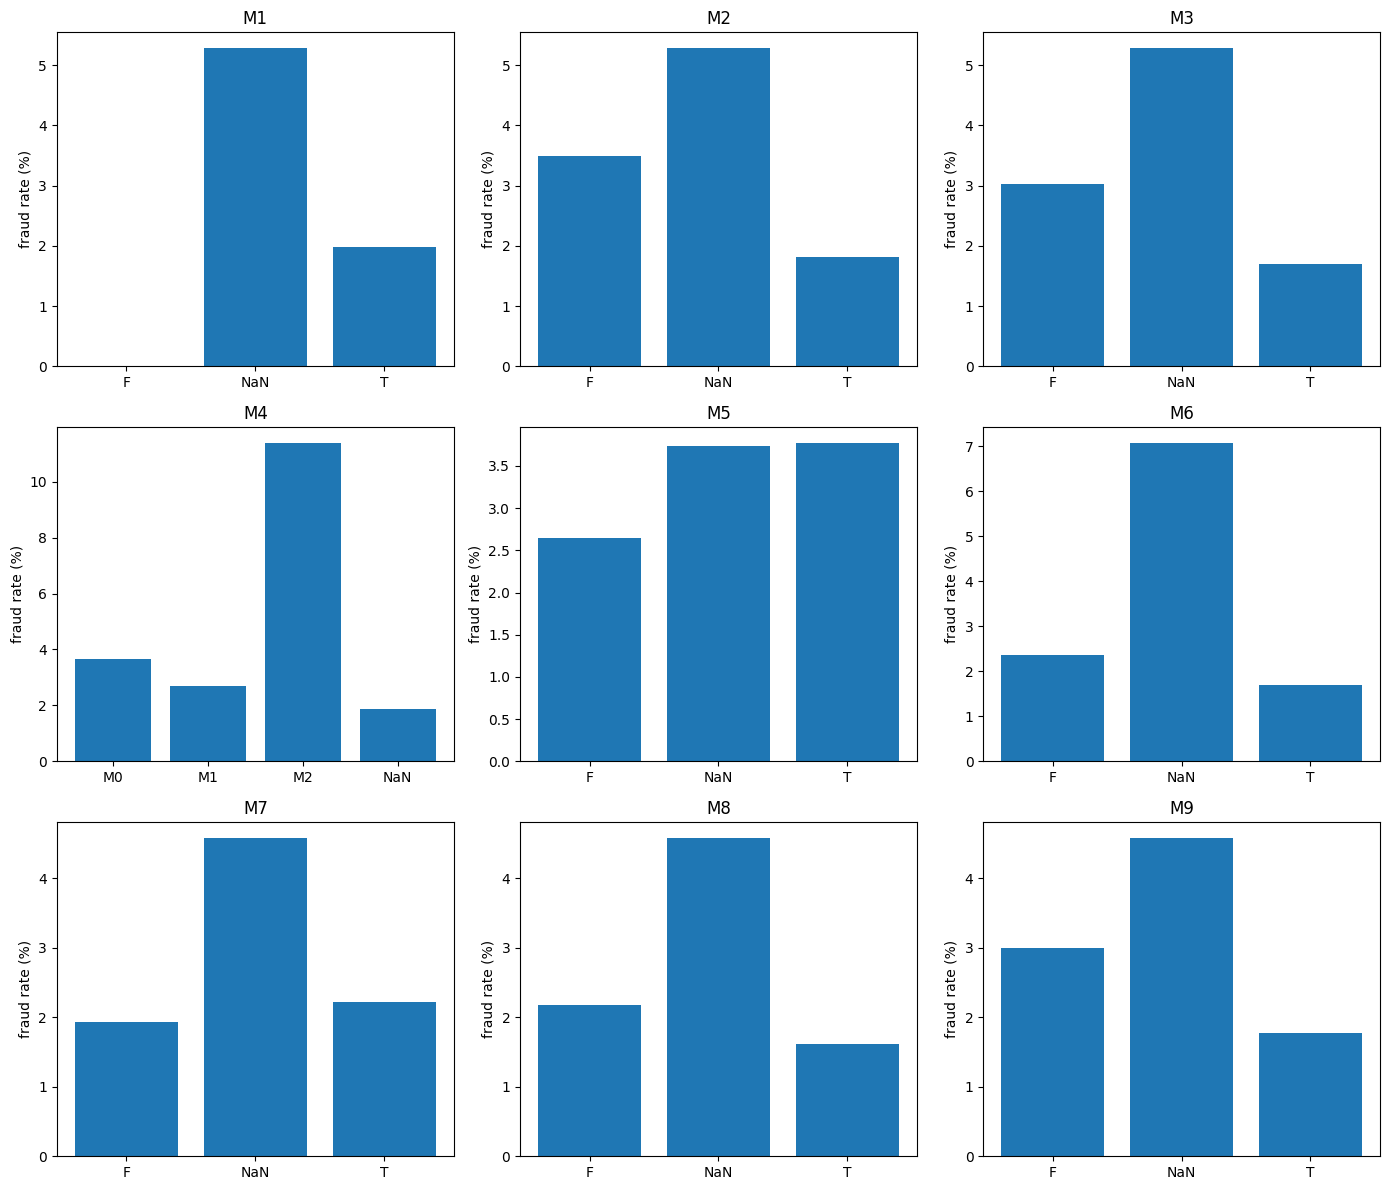

In [18]:
m_cols = [c for c in ['M1','M2','M3','M4','M5','M6','M7','M8','M9'] if c in df.columns]

ncols = 3
nrows = (len(m_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(m_cols):
    rate = (df.assign(**{col: df[col].fillna('NaN').astype(str)})
              .groupby(col)[config.TARGET].mean() * 100)
    axes[i].bar(rate.index, rate.values)
    axes[i].set_title(col)
    axes[i].set_ylabel('fraud rate (%)')

for j in range(len(m_cols), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'match_fields_fraud_rate.png')
plt.show()
plt.close()

## 6. Correlation with Target

Linear correlation only. Tree-based models will capture non-linear signals; this is a quick directional scan.

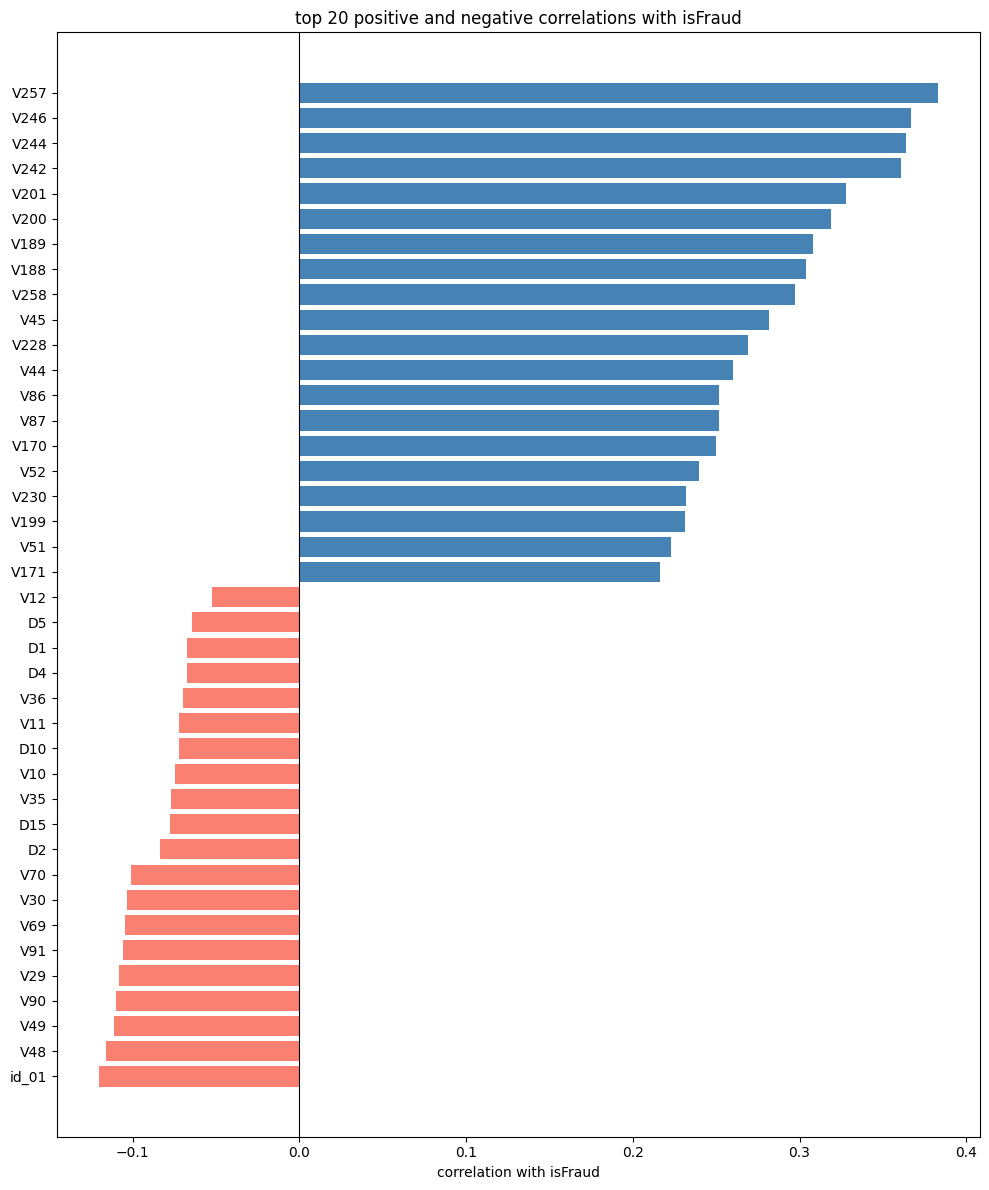

In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop(config.TARGET, errors='ignore')
corr = df[numeric_cols].corrwith(df[config.TARGET]).dropna().sort_values()

plot_corr = pd.concat([corr.head(20), corr.tail(20)])
colors = ['salmon' if v < 0 else 'steelblue' for v in plot_corr.values]

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(plot_corr.index, plot_corr.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('correlation with isFraud')
ax.set_title('top 20 positive and negative correlations with isFraud')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'correlation_with_target.png')
plt.show()
plt.close()

## Relative Trigger Rate Analysis

Identify binary features with meaningfully different activation rates between fraud and non-fraud transactions.

In [20]:
for col in ['M1','M2','M3','M4','M5','M6','M7','M8','M9']:
    df[col] = (df[col] == 'T').astype(int)

df['is_mobile']     = (df['DeviceType'] == 'mobile').astype(int)
df['is_credit']     = (df['card6'] == 'credit').astype(int)
df['is_visa']       = (df['card4'] == 'visa').astype(int)
df['is_mastercard'] = (df['card4'] == 'mastercard').astype(int)
df['is_amex']       = (df['card4'] == 'amex').astype(int)
df['is_discover']   = (df['card4'] == 'discover').astype(int)
df['p_email_gmail'] = (df['P_emaildomain'] == 'gmail.com').astype(int)
df['r_email_gmail'] = (df['R_emaildomain'] == 'gmail.com').astype(int)
df['is_product_W']  = (df['ProductCD'] == 'W').astype(int)
df['has_identity']  = df['DeviceType'].notna().astype(int)

binary_vars = [
    'M1','M2','M3','M4','M5','M6','M7','M8','M9',
    'is_mobile','is_credit',
    'is_visa','is_mastercard','is_amex','is_discover',
    'p_email_gmail','r_email_gmail',
    'is_product_W','has_identity'
]

,isFraud,not_isFraud,ix,n_fraud,n_non_fraud
r_email_gmail,0.329623,0.088328,373.0,6811,50336
is_mobile,0.273774,0.087717,312.0,5657,49988
has_identity,0.542564,0.227416,239.0,11211,129599
is_discover,0.024875,0.010769,231.0,514,6137
is_credit,0.481537,0.243975,197.0,9950,139036
p_email_gmail,0.481198,0.383262,126.0,9943,218412
M7,0.035232,0.056456,62.0,728,32173
is_product_W,0.434061,0.755779,57.0,8969,430701
M1,0.306925,0.549369,56.0,6342,313073
M2,0.249625,0.491878,51.0,5158,280310


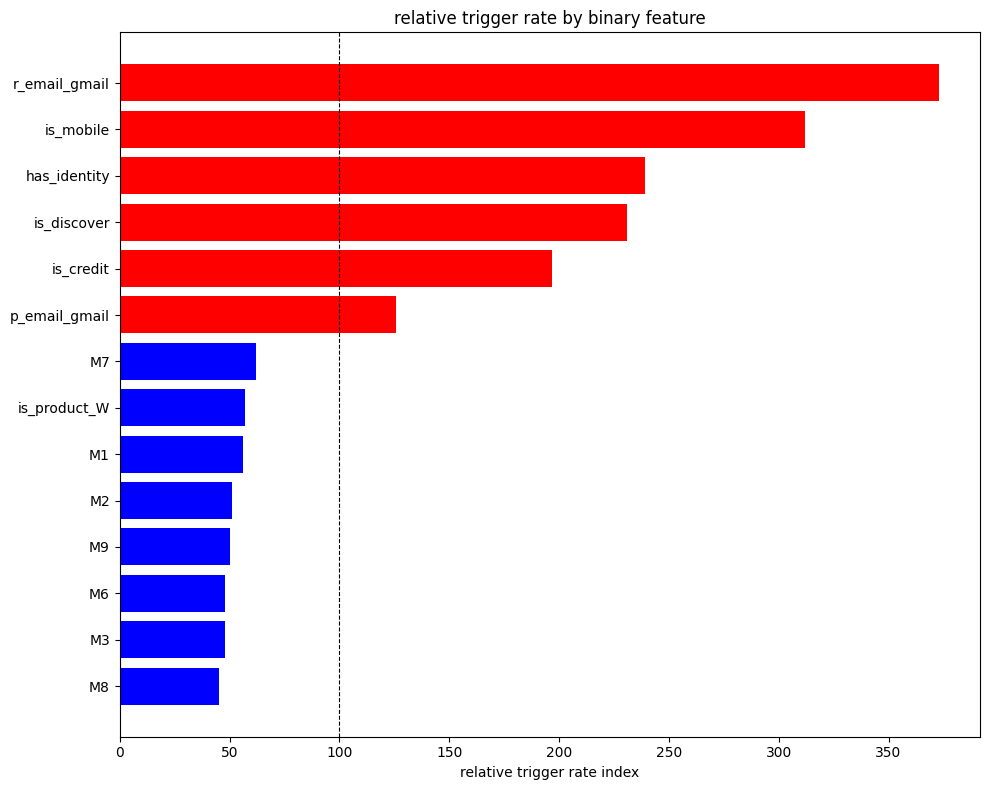

In [21]:
from src.utils import get_relative_trigger

upper_thresh = 120
lower_thresh = 70

rtr = get_relative_trigger(df, config.TARGET, binary_vars, upper_thresh, lower_thresh)
display(rtr)

plot_rtr = rtr.sort_values('ix', ascending=True)
colors = ['red' if v > upper_thresh else 'blue' if v < lower_thresh else 'grey'
          for v in plot_rtr['ix']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_rtr.index, plot_rtr['ix'], color=colors)
ax.axvline(x=100, linestyle='--', color='black', linewidth=0.8)
ax.set_xlabel('relative trigger rate index')
ax.set_title('relative trigger rate by binary feature')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'relative_trigger_rate.png')
plt.show()
plt.close()

ix = (rate in fraud) / (rate in non-fraud) x 100. A value of 100 means equal rates in both classes. ix > 120 means the feature fires more in fraud. ix < 70 means it fires less in fraud — an inverse signal. Only features outside the neutral band are shown.

Results:
- Discover card fraud rate 2x baseline. May have weak fraud controls
- Fraud more common on mobile, credit, recipient email = gmail,
- Fraud less common with verification match... this is intuitive. M7 least effective. 
- Product W less likely to be fraud

